# Caso de Estudio: CNN para Reconocimiento de Dígitos

## Objetivo
Desarrollar un sistema de reconocimiento de dígitos basado en una Red Neuronal Convolucional (CNN) utilizando el dataset MNIST para aplicaciones en ruteo automático de correspondencia.

## 1. Business Case Discovery

### 1.1 Contexto del Negocio
Una importante compañía de envíos necesita modernizar su sistema de ruteo. El reconocimiento automático de los dígitos del código postal en paquetes puede agilizar el proceso y reducir costos operativos.

### 1.2 Objetivo del Proyecto
Desarrollar un modelo CNN que:
- Identifique correctamente los dígitos del código postal en imágenes de paquetes
- Automatice el ruteo según el código postal

### 1.3 Métricas de Éxito
- **Precisión (Accuracy):** Porcentaje de dígitos reconocidos correctamente
- **Tiempo de Inferencia:** Tiempo para procesar cada imagen
- **Número de Parámetros:** Eficiencia del modelo

### 1.4 Desafíos
- Variabilidad en iluminación, ángulos y ruido
- Evitar sobreajuste y subajuste del modelo

## 2. Data Processing

### 2.1 Dataset MNIST
- 70,000 imágenes en escala de grises (28x28 píxeles)
- Dígitos manuscritos (0-9)
- Descargable desde TensorFlow/Keras o Kaggle

### 2.2 Análisis Exploratorio
El alumno deberá:
- Visualizar muestras de dígitos
- Analizar la distribución de clases
- Detectar anomalías o sesgos

### 2.3 Preprocesamiento
- Normalización: dividir por 255 para escalar al rango [0,1]
- Data Augmentation: rotaciones, traslaciones, zoom, cambios de brillo
- Conversión de formatos: forma correcta (n_samples, 28, 28, 1)

### 2.4 División de Datos
- Entrenamiento: 70%
- Validación: 15%
- Prueba: 15%

In [14]:
# Importar librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np


In [15]:
# 2.1 Cargar el dataset MNIST

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

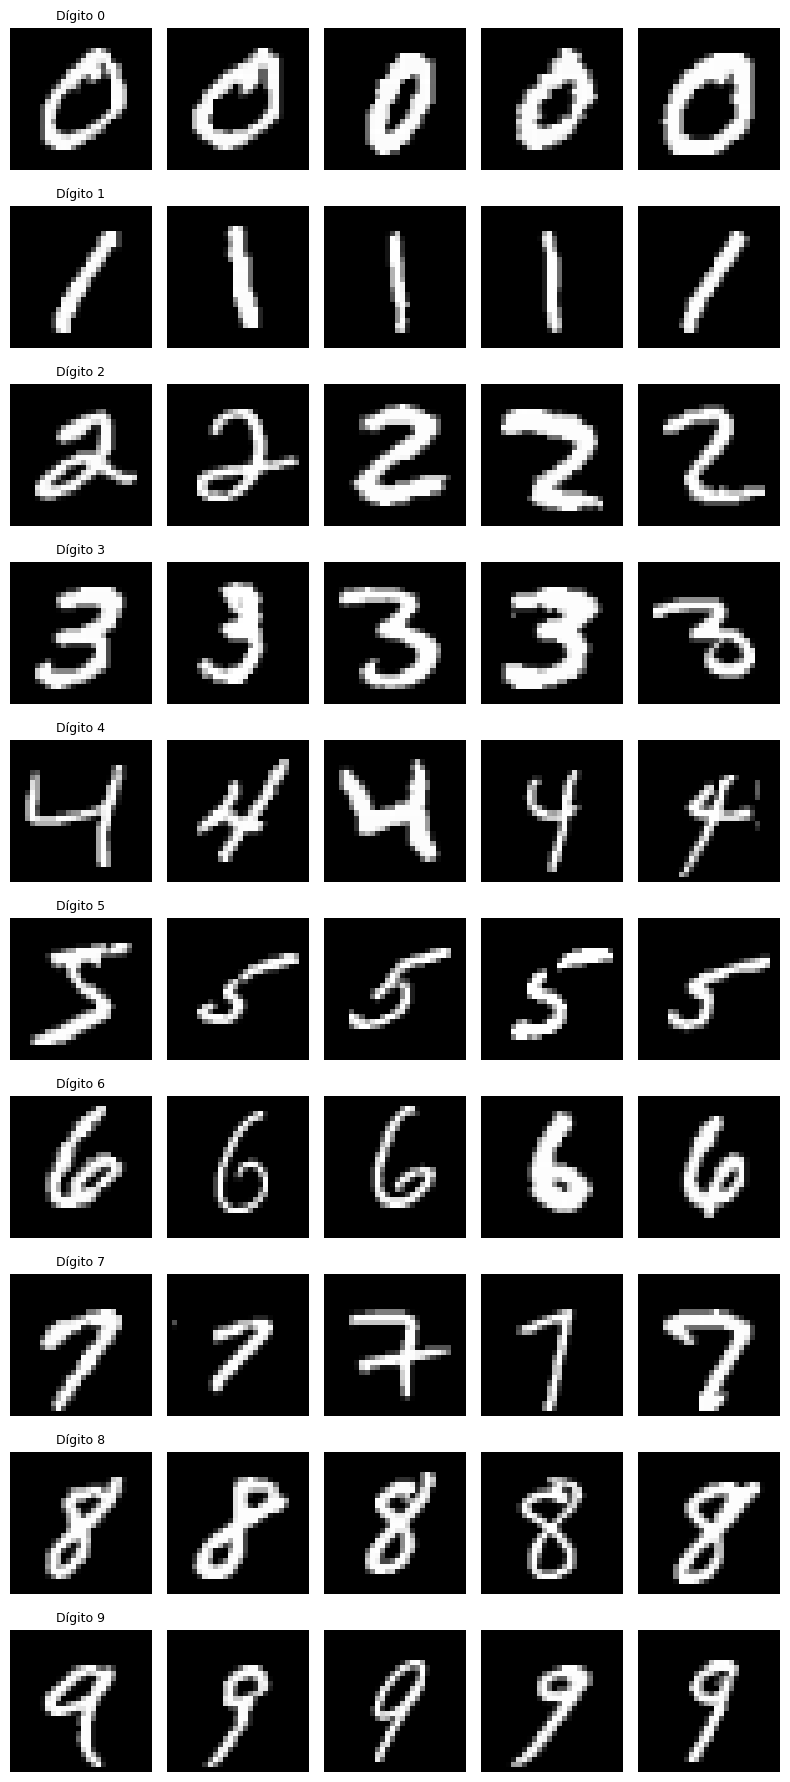

In [16]:
# 2.2 Análisis Exploratorio - Visualizar muestras de dígitos
fig, axes = plt.subplots(10, 5, figsize=(8, 18))
for digit in range(10):
    indices = np.where(y_train == digit)[0][:5]
    for j, idx in enumerate(indices):
        axes[digit, j].imshow(x_train[idx], cmap='gray')
        axes[digit, j].axis('off')
        if j == 0:
            axes[digit, j].set_title(f"Dígito {digit}", fontsize=9)
plt.tight_layout()
plt.show()


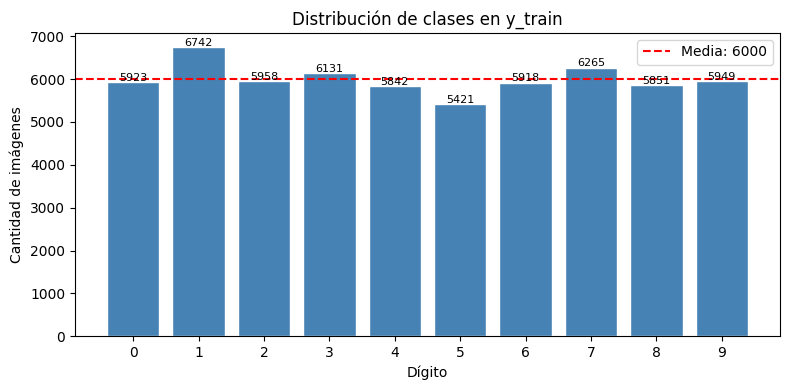

In [17]:
# 2.2 Análisis de distribución de clases

unique, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(8, 4))
bars = plt.bar(unique, counts, color='steelblue', edgecolor='white')
plt.axhline(counts.mean(), color='red', linestyle='--', label=f'Media: {counts.mean():.0f}')
plt.xlabel('Dígito')
plt.ylabel('Cantidad de imágenes')
plt.title('Distribución de clases en y_train')
plt.xticks(range(10))
plt.legend()
# Anotar el valor encima de cada barra
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             str(count), ha='center', fontsize=8)
plt.tight_layout()
plt.show()

In [18]:
# 2.3 Normalización de datos
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

In [19]:
# 2.3 Reshape de imágenes para CNN (añadir dimensión de canal)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

In [20]:
# 2.3 Codificación one-hot de etiquetas
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [21]:
# 2.4 División de datos en entrenamiento, validación y prueba
from sklearn.model_selection import train_test_split
x_train, x_val, y_train, y_val = train_test_split(
    x_train, 
    y_train, 
    test_size=0.1, 
    random_state=42
)

## 3. Model Planning

### 3.1 Definición del Problema
- **Tipo:** Clasificación de imágenes
- **Clases:** 10 (dígitos 0-9)

### 3.2 Criterios de Entrenamiento
- Preparar correctamente los datos
- Entrenar con flujo train/validación/test
- Monitorizar métricas para detectar sobreajuste

### 3.3 Función de Pérdida y Evaluación
- Función de pérdida: categorical_crossentropy
- Métrica: precisión (accuracy)

## 4. Model Building and Selection

### 4.1 Construcción de la CNN
Implementar una CNN con:
- Capas convolucionales
- Capas de pooling
- Capas densas
- Función de activación ReLU
- Dropout para regularización

### 4.2 Entrenamiento
- Optimizador: Adam
- Número de épocas: comenzar con valores moderados
- Batch size: ajustar según disponibilidad de recursos
- Early Stopping: si es necesario

In [22]:
# 4.1 Definir la arquitectura de la CNN
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(10, activation="softmax")
])


In [23]:
# 4.1 Compilar el modelo

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241,546 (943.54 KB)

 Trainable params: 241,546 (943.54 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
# 4.2 Entrenar el modelo
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=5, restore_best_weights=True
    ),
    keras.callbacks.ModelCheckpoint(
        filepath="cnn_mnist_ruteo_paquetes.keras",monitor="val_loss", save_best_only=True, verbose=1
    )
]

history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=50,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/50
841/844 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8277 - loss: 0.5416
Epoch 1: val_loss improved from None to 0.04785, saving model to cnn_mnist_ruteo_paquetes.keras

Epoch 1: finished saving model to cnn_mnist_ruteo_paquetes.keras
844/844 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.9256 - loss: 0.2434 - val_accuracy: 0.9860 - val_loss: 0.0478
Epoch 2/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9774 - loss: 0.0764
Epoch 2: val_loss improved from 0.04785 to 0.03409, saving model to cnn_mnist_ruteo_paquetes.keras

Epoch 2: finished saving model to cnn_mnist_ruteo_paquetes.keras
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9799 - loss: 0.0682 - val_accuracy: 0.9902 - val_loss: 0.0341
Epoch 3/50
842/844 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9858 - loss: 0.0494
Epoch 3: val_loss improved from 0.03409 to 0.03117, saving model to cnn_mnist_ruteo_paquetes.keras

Epoch 3: finished saving model to cnn_mnist_ruteo_paquetes.keras
844/844 ━

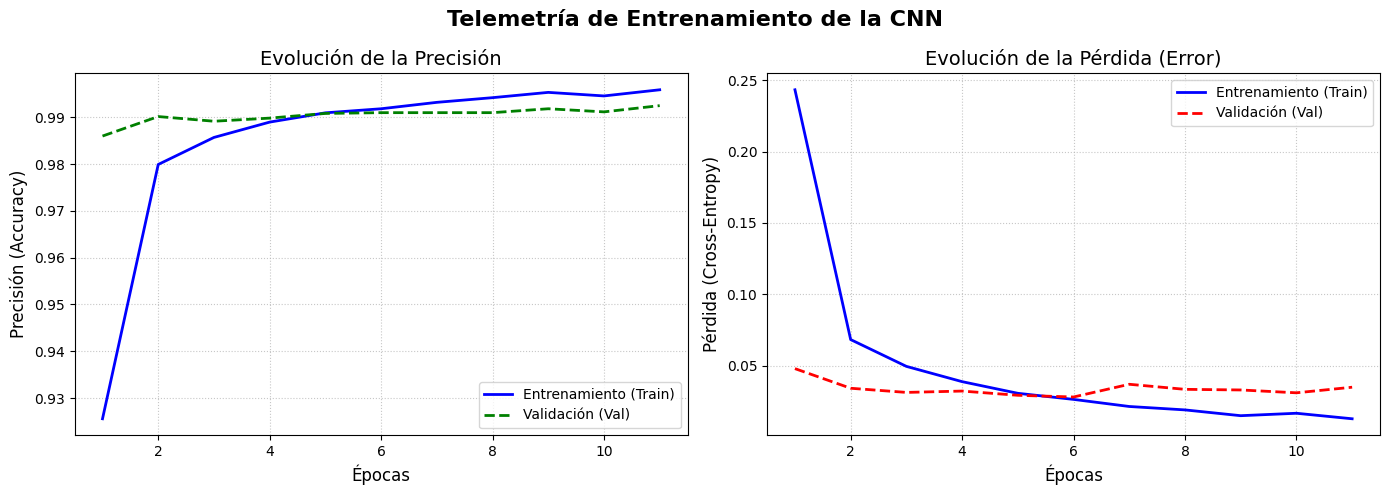

In [ ]:
# 4.2 Visualizar las curvas de entrenamiento (loss y accuracy)


import matplotlib.pyplot as plt

# =====================================================================
# # 4.2 VISUALIZAR LAS CURVAS DE ENTRENAMIENTO
# =====================================================================

def graficar_telemetria(historial):
    # --- 1. EXTRACCIÓN DE DATOS DEL DICCIONARIO ---
    # Extraemos las listas de valores registrados en cada época
    acc = historial.history['accuracy']
    val_acc = historial.history['val_accuracy']
    loss = historial.history['loss']
    val_loss = historial.history['val_loss']
    
    # Calculamos el número real de épocas que se ejecutaron 
    # (importante porque EarlyStopping pudo haber cortado antes de las 50)
    epocas_reales = range(1, len(acc) + 1)
    
    # --- 2. CONFIGURACIÓN DEL LIENZO (1 Fila, 2 Columnas) ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Telemetría de Entrenamiento de la CNN', fontsize=16, fontweight='bold')
    
    # --- 3. GRÁFICO 1: CURVA DE PRECISIÓN (ACCURACY) ---
    axes[0].plot(epocas_reales, acc, 'b-', label='Entrenamiento (Train)', linewidth=2)
    axes[0].plot(epocas_reales, val_acc, 'g--', label='Validación (Val)', linewidth=2)
    axes[0].set_title('Evolución de la Precisión', fontsize=14)
    axes[0].set_xlabel('Épocas', fontsize=12)
    axes[0].set_ylabel('Precisión (Accuracy)', fontsize=12)
    axes[0].legend(loc='lower right')
    axes[0].grid(True, linestyle=':', alpha=0.7)
    
    # --- 4. GRÁFICO 2: CURVA DE PÉRDIDA (LOSS) ---
    axes[1].plot(epocas_reales, loss, 'b-', label='Entrenamiento (Train)', linewidth=2)
    axes[1].plot(epocas_reales, val_loss, 'r--', label='Validación (Val)', linewidth=2)
    axes[1].set_title('Evolución de la Pérdida (Error)', fontsize=14)
    axes[1].set_xlabel('Épocas', fontsize=12)
    axes[1].set_ylabel('Pérdida (Cross-Entropy)', fontsize=12)
    axes[1].legend(loc='upper right')
    axes[1].grid(True, linestyle=':', alpha=0.7)
    
    # Renderizar
    plt.tight_layout()
    plt.show()

# Llamamos a la función pasándole nuestro objeto history
graficar_telemetria(history)

## 5. Presentación de Resultados

### 5.1 Análisis Cuantitativo
- Precisión en train, validación y test
- Evolución del loss

### 5.2 Visualización de Resultados
- Curvas de entrenamiento
- Matriz de confusión
- Análisis de errores

### 5.3 Reflexión Crítica
- ¿Generaliza bien el modelo?
- ¿Hay sobreajuste?
- Posibles mejoras

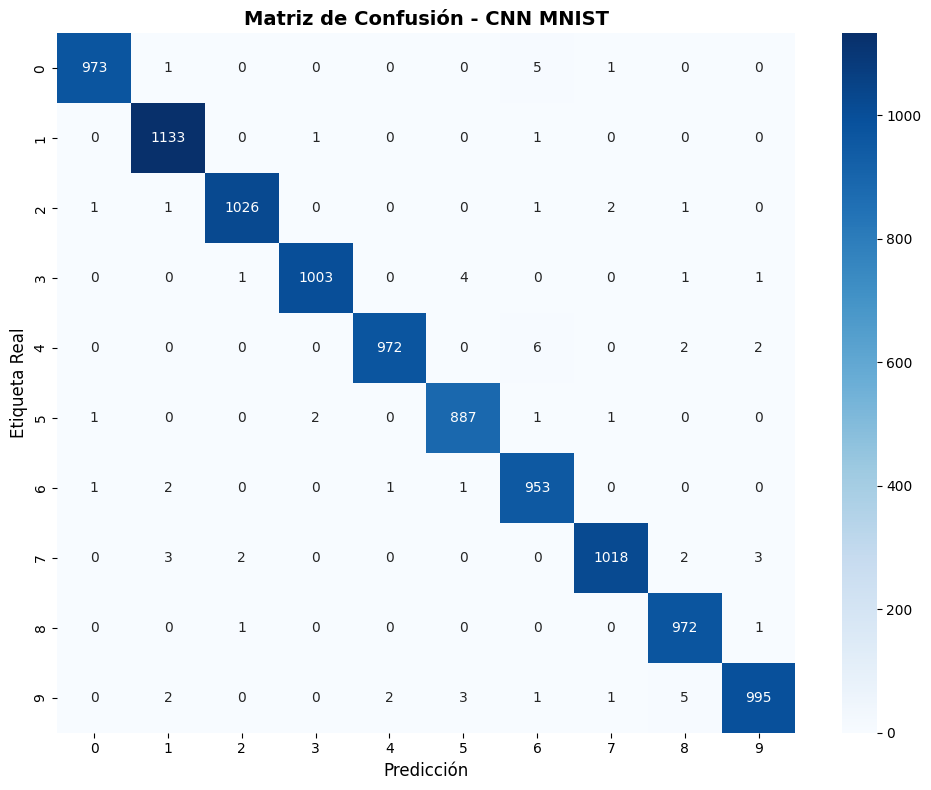

In [34]:
# 5.2 Matriz de confusión
# Realizar predicciones en el conjunto de prueba
y_pred = model.predict(x_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

# Calcular matriz de confusión
cm = confusion_matrix(y_test_classes, y_pred_classes)

# Visualizar
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=range(10), yticklabels=range(10))
plt.title('Matriz de Confusión - CNN MNIST', fontsize=14, fontweight='bold')
plt.xlabel('Predicción', fontsize=12)
plt.ylabel('Etiqueta Real', fontsize=12)
plt.tight_layout()
plt.show()

In [35]:
# 5.2 Reporte de clasificación
print("=" * 60)
print("REPORTE DE CLASIFICACIÓN - CNN MNIST")
print("=" * 60)
print("\n" + classification_report(y_test_classes, y_pred_classes, 
                                   target_names=[str(i) for i in range(10)]))
print("=" * 60)

# Evaluación general
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"\nPrecisión en conjunto de prueba: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Pérdida en conjunto de prueba: {test_loss:.4f}")

REPORTE DE CLASIFICACIÓN - CNN MNIST

              precision    recall  f1-score   support

           0       1.00      0.99      0.99       980
           1       0.99      1.00      1.00      1135
           2       1.00      0.99      1.00      1032
           3       1.00      0.99      1.00      1010
           4       1.00      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.98      0.99      0.99       958
           7       1.00      0.99      0.99      1028
           8       0.99      1.00      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000


Precisión en conjunto de prueba: 0.9932 (99.32%)
Pérdida en conjunto de prueba: 0.0237


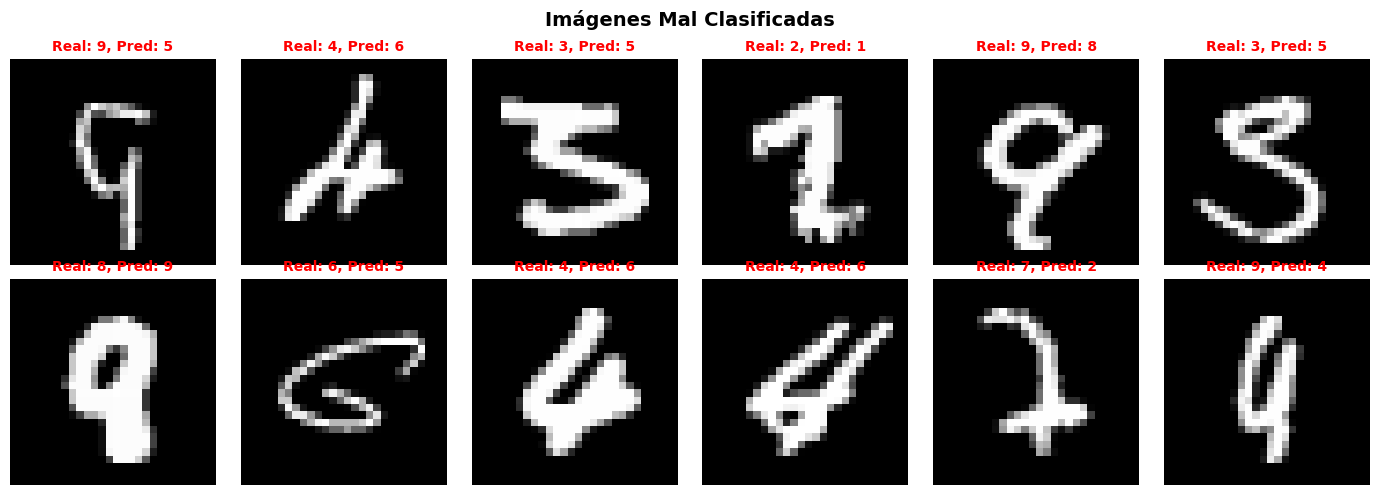


Total de errores: 68 / 10000
Tasa de error: 0.68%


In [36]:
# 5.2 Análisis de errores - Mostrar imágenes mal clasificadas
# Identificar predicciones incorrectas
incorrect_indices = np.where(y_pred_classes != y_test_classes)[0]

# Mostrar las primeras 12 imágenes mal clasificadas
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
fig.suptitle('Imágenes Mal Clasificadas', fontsize=14, fontweight='bold')

for idx, axis in enumerate(axes.flat):
    if idx < len(incorrect_indices):
        i = incorrect_indices[idx]
        # Desnormalizar para visualizar
        image = x_test[i].reshape(28, 28) * 255
        axis.imshow(image, cmap='gray')
        axis.set_title(f'Real: {y_test_classes[i]}, Pred: {y_pred_classes[i]}', 
                      color='red', fontweight='bold', fontsize=10)
        axis.axis('off')
    else:
        axis.axis('off')

plt.tight_layout()
plt.show()

print(f"\nTotal de errores: {len(incorrect_indices)} / {len(y_test_classes)}")
print(f"Tasa de error: {len(incorrect_indices)/len(y_test_classes)*100:.2f}%")

## 6. Deployment

### 6.1 Serialización del Modelo
Guardar el modelo en formato `.h5` o `.keras`

### 6.2 API para Inferencia
Crear un endpoint con Flask o FastAPI

### 6.3 Interfaz Web (Opcional)
Streamlit u otra alternativa para subir imágenes

In [39]:
# 6.1 Guardar el modelo
# Guardar en formato .keras (recomendado para Keras 3)
modelo_path = "cnn_mnist_ruteo_paquetes.keras"
model.save(modelo_path)
print(f"✓ Modelo guardado en: {modelo_path}")


✓ Modelo guardado en: cnn_mnist_ruteo_paquetes.keras
